# Self-Supervised Learning: SimCLR-style Contrastive Pretraining

This notebook implements a self-supervised learning experiment for the BostonGene IML-2 painting-style classification task.

The model is trained without using class labels. For each image, two augmented views are created. The encoder is trained to make the representations of two views of the same image similar, while making representations of different images less similar.

This experiment is added as a bonus self-supervised learning component. It does not replace the required supervised classifier or the required VAE embedding/clustering part.

In [ ]:
from pathlib import Path
import sys
import os
import shutil
import zipfile

# ============================================================
# 1. Detect environment
# ============================================================

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

    DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/bostongene_project")
    DRIVE_ZIP = DRIVE_PROJECT_DIR / "bostongene_classifier_bundle.zip"

    print("Drive project folder:", DRIVE_PROJECT_DIR)
    print("Expected zip:", DRIVE_ZIP)

    assert DRIVE_PROJECT_DIR.exists(), f"Drive folder not found: {DRIVE_PROJECT_DIR}"
    assert DRIVE_ZIP.exists(), f"Zip file not found: {DRIVE_ZIP}"

    WORK_DIR = Path("/content/bostongene_project")

    if WORK_DIR.exists():
        shutil.rmtree(WORK_DIR)

    WORK_DIR.mkdir(parents=True, exist_ok=True)

    print("Extracting project zip...")

    with zipfile.ZipFile(DRIVE_ZIP, "r") as zip_ref:
        for member in zip_ref.namelist():
            correct_path = member.replace("\\", "/")
            target_path = WORK_DIR / correct_path

            if correct_path.endswith("/"):
                target_path.mkdir(parents=True, exist_ok=True)
            else:
                target_path.parent.mkdir(parents=True, exist_ok=True)
                with zip_ref.open(member) as source, open(target_path, "wb") as target:
                    target.write(source.read())

    print("Unzipped into:", WORK_DIR)

else:
    WORK_DIR = Path.cwd().resolve()

    if WORK_DIR.name == "notebooks":
        WORK_DIR = WORK_DIR.parent


# ============================================================
# 2. Find project root
# ============================================================

src_dirs = list(WORK_DIR.rglob("src"))

assert len(src_dirs) > 0, (
    "Could not find src directory. "
    "Make sure you launched the notebook from the project root or extracted the zip correctly."
)

PROJECT_ROOT = src_dirs[0].parent

assert (PROJECT_ROOT / "data").exists(), "data/ folder is missing."
assert (PROJECT_ROOT / "notebooks").exists(), "notebooks/ folder is missing."
assert (PROJECT_ROOT / "src" / "data.py").exists(), "src/data.py is missing."
assert (PROJECT_ROOT / "src" / "config.py").exists(), "src/config.py is missing."

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("IN_COLAB:", IN_COLAB)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Current working directory:", Path.cwd())

Mounted at /content/drive
Drive project folder: /content/drive/MyDrive/bostongene_project
Expected zip: /content/drive/MyDrive/bostongene_project/bostongene_classifier_bundle.zip
Extracting project zip...
Unzipped into: /content/bostongene_project
IN_COLAB: True
PROJECT_ROOT: /content/bostongene_project/image_classification_project
Current working directory: /content/bostongene_project/image_classification_project


In [ ]:
import random
import time
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import resnet18

from src.data import PadToSquare
from src.config import TRAIN_DIR, VAL_DIR, TEST_DIR, MODELS_DIR, OUTPUTS_DIR, FIGURES_DIR, NUM_CLASSES, SEED


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("TEST_DIR:", TEST_DIR)

assert TRAIN_DIR.exists(), f"Train directory not found: {TRAIN_DIR}"
assert VAL_DIR.exists(), f"Validation directory not found: {VAL_DIR}"
assert TEST_DIR.exists(), f"Test directory not found: {TEST_DIR}"

Device: cuda
TRAIN_DIR: /content/bostongene_project/image_classification_project/data/processed/train
VAL_DIR: /content/bostongene_project/image_classification_project/data/processed/val
TEST_DIR: /content/bostongene_project/image_classification_project/data/processed/test


In [ ]:
IMG_SIZE_SSL = 128

# SimCLR benefits from large batches, but Colab GPU memory is limited.
# If you get CUDA out-of-memory, reduce this to 32.
SSL_BATCH_SIZE = 64 if device.type == "cuda" else 16

NUM_WORKERS_SSL = 2 if device.type == "cuda" else 0


class ContrastiveTransform:
    """
    Given one PIL image, return two independently augmented views.

    These two views form a positive pair for SimCLR.
    """

    def __init__(self, base_transform):
        self.base_transform = base_transform

    def __call__(self, image):
        view_1 = self.base_transform(image)
        view_2 = self.base_transform(image)
        return view_1, view_2


ssl_base_transform = transforms.Compose([
    PadToSquare(fill=(0, 0, 0)),
    transforms.RandomResizedCrop(
        size=IMG_SIZE_SSL,
        scale=(0.55, 1.0),
        ratio=(0.75, 1.33),
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply(
        [
            transforms.ColorJitter(
                brightness=0.35,
                contrast=0.35,
                saturation=0.35,
                hue=0.08,
            )
        ],
        p=0.8,
    ),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(kernel_size=9, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

ssl_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=ContrastiveTransform(ssl_base_transform),
)

ssl_loader = DataLoader(
    ssl_dataset,
    batch_size=SSL_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS_SSL,
    pin_memory=(device.type == "cuda"),
    drop_last=True,
)

print("SSL training images:", len(ssl_dataset))
print("SSL batch size:", SSL_BATCH_SIZE)
print("Number of SSL batches:", len(ssl_loader))
print("Classes exist in dataset, but labels will be ignored during SSL:")
print(ssl_dataset.classes)

SSL training images: 995
SSL batch size: 64
Number of SSL batches: 15
Classes exist in dataset, but labels will be ignored during SSL:
['ArtDeco', 'Cubism', 'Impressionism', 'Japonism', 'Naturalism', 'Rococo', 'cartoon', 'photo']


In [ ]:
(views_1, views_2), labels = next(iter(ssl_loader))

print("View 1 batch:", views_1.shape)
print("View 2 batch:", views_2.shape)
print("Labels shape:", labels.shape)
print("Labels are loaded but ignored during SimCLR pretraining.")

View 1 batch: torch.Size([64, 3, 128, 128])
View 2 batch: torch.Size([64, 3, 128, 128])
Labels shape: torch.Size([64])
Labels are loaded but ignored during SimCLR pretraining.


In [ ]:
class SimCLRModel(nn.Module):
    """
    ResNet18 encoder + projection head for SimCLR.

    The encoder learns image representations.
    The projection head is used only during contrastive pretraining.
    """

    def __init__(self, projection_dim: int = 128):
        super().__init__()

        backbone = resnet18(weights=None)

        feature_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()

        self.encoder = backbone

        self.projection_head = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, projection_dim),
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projection_head(h)
        return h, z


simclr_model = SimCLRModel(projection_dim=128).to(device)

print(simclr_model)

SimCLRModel(
  (encoder): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [ ]:
def nt_xent_loss(z1, z2, temperature: float = 0.5):
    """
    Normalized Temperature-scaled Cross Entropy Loss.

    z1 and z2 are projected representations of two augmented views
    of the same batch of images.
    """
    batch_size = z1.size(0)

    z = torch.cat([z1, z2], dim=0)
    z = F.normalize(z, dim=1)

    similarity_matrix = torch.matmul(z, z.T) / temperature

    # Remove self-similarity from the denominator
    mask = torch.eye(2 * batch_size, dtype=torch.bool, device=z.device)
    similarity_matrix = similarity_matrix.masked_fill(mask, -1e9)

    # Positive pair index:
    # first half matches second half, second half matches first half
    targets = torch.arange(2 * batch_size, device=z.device)
    targets = (targets + batch_size) % (2 * batch_size)

    loss = F.cross_entropy(similarity_matrix, targets)

    return loss

In [ ]:
EPOCHS_SSL = 1 if device.type == "cpu" else 50

optimizer_ssl = torch.optim.AdamW(
    simclr_model.parameters(),
    lr=3e-4,
    weight_decay=1e-4,
)

scheduler_ssl = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ssl,
    T_max=EPOCHS_SSL,
)

best_ssl_loss = float("inf")
history_ssl = []

ssl_checkpoint_path = MODELS_DIR / "simclr_resnet18_ssl.pt"

print(f"Training SimCLR for {EPOCHS_SSL} epoch(s)")
print(f"Checkpoint will be saved to: {ssl_checkpoint_path}")

start_time = time.time()

for epoch in range(1, EPOCHS_SSL + 1):
    simclr_model.train()

    running_loss = 0.0
    n_samples = 0

    epoch_start = time.time()

    for (x1, x2), _ in ssl_loader:
        x1 = x1.to(device)
        x2 = x2.to(device)

        optimizer_ssl.zero_grad(set_to_none=True)

        _, z1 = simclr_model(x1)
        _, z2 = simclr_model(x2)

        loss = nt_xent_loss(z1, z2, temperature=0.5)

        loss.backward()
        optimizer_ssl.step()

        batch_size = x1.size(0)
        running_loss += loss.item() * batch_size
        n_samples += batch_size

    scheduler_ssl.step()

    epoch_loss = running_loss / n_samples
    current_lr = optimizer_ssl.param_groups[0]["lr"]

    history_ssl.append({
        "epoch": epoch,
        "ssl_loss": epoch_loss,
        "lr": current_lr,
    })

    improved = epoch_loss < best_ssl_loss

    if improved:
        best_ssl_loss = epoch_loss

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": simclr_model.state_dict(),
                "encoder_state_dict": simclr_model.encoder.state_dict(),
                "projection_head_state_dict": simclr_model.projection_head.state_dict(),
                "ssl_loss": best_ssl_loss,
                "config": {
                    "architecture": "ResNet18 SimCLR",
                    "img_size": IMG_SIZE_SSL,
                    "batch_size": SSL_BATCH_SIZE,
                    "projection_dim": 128,
                    "temperature": 0.5,
                    "pretraining_data": "train split only",
                    "labels_used": False,
                },
            },
            ssl_checkpoint_path,
        )

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch {epoch:03d}/{EPOCHS_SSL} | "
        f"ssl_loss={epoch_loss:.4f} | "
        f"best_ssl_loss={best_ssl_loss:.4f} | "
        f"lr={current_lr:.6f} | "
        f"time={epoch_time:.1f}s"
    )

total_time = time.time() - start_time

print(f"SSL pretraining finished in {total_time / 60:.2f} minutes.")
print(f"Best SSL loss: {best_ssl_loss:.4f}")

Training SimCLR for 50 epoch(s)
Checkpoint will be saved to: /content/bostongene_project/image_classification_project/models/simclr_resnet18_ssl.pt
Epoch 001/50 | ssl_loss=4.2583 | best_ssl_loss=4.2583 | lr=0.000300 | time=14.5s
Epoch 002/50 | ssl_loss=3.9094 | best_ssl_loss=3.9094 | lr=0.000299 | time=14.5s
Epoch 003/50 | ssl_loss=3.7966 | best_ssl_loss=3.7966 | lr=0.000297 | time=14.4s
Epoch 004/50 | ssl_loss=3.6872 | best_ssl_loss=3.6872 | lr=0.000295 | time=14.7s
Epoch 005/50 | ssl_loss=3.6240 | best_ssl_loss=3.6240 | lr=0.000293 | time=14.4s
Epoch 006/50 | ssl_loss=3.5560 | best_ssl_loss=3.5560 | lr=0.000289 | time=15.0s
Epoch 007/50 | ssl_loss=3.5280 | best_ssl_loss=3.5280 | lr=0.000286 | time=14.2s
Epoch 008/50 | ssl_loss=3.4731 | best_ssl_loss=3.4731 | lr=0.000281 | time=14.2s
Epoch 009/50 | ssl_loss=3.4548 | best_ssl_loss=3.4548 | lr=0.000277 | time=13.2s
Epoch 010/50 | ssl_loss=3.4405 | best_ssl_loss=3.4405 | lr=0.000271 | time=13.4s
Epoch 011/50 | ssl_loss=3.4210 | best_ssl_

,epoch,ssl_loss,lr
0,1,4.258314,0.000300
1,2,3.909385,0.000299
2,3,3.796574,0.000297
3,4,3.687218,0.000295
4,5,3.623980,0.000293


,epoch,ssl_loss,lr
45,46,3.183657,4.712526e-06
46,47,3.179704,2.656912e-06
47,48,3.192610,1.182795e-06
48,49,3.180688,2.959907e-07
49,50,3.178087,0.000000e+00


Saved SSL history to: /content/bostongene_project/image_classification_project/outputs/simclr_ssl_pretraining_history.csv


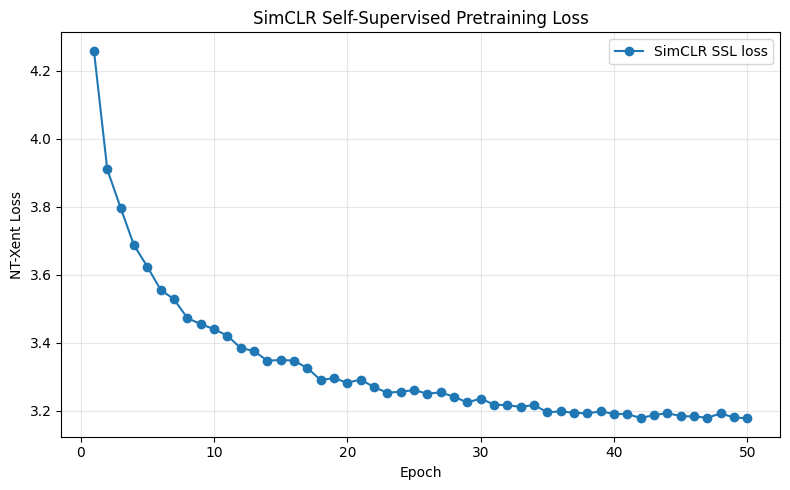

Saved SSL loss curve to: /content/bostongene_project/image_classification_project/reports/figures/13_simclr_ssl_loss_curve.png


In [ ]:
history_ssl_df = pd.DataFrame(history_ssl)

ssl_history_path = OUTPUTS_DIR / "simclr_ssl_pretraining_history.csv"
history_ssl_df.to_csv(ssl_history_path, index=False)

display(history_ssl_df.head())
display(history_ssl_df.tail())

print(f"Saved SSL history to: {ssl_history_path}")

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    history_ssl_df["epoch"],
    history_ssl_df["ssl_loss"],
    marker="o",
    label="SimCLR SSL loss",
)

ax.set_title("SimCLR Self-Supervised Pretraining Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("NT-Xent Loss")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

ssl_loss_fig_path = FIGURES_DIR / "13_simclr_ssl_loss_curve.png"
fig.savefig(ssl_loss_fig_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved SSL loss curve to: {ssl_loss_fig_path}")

In [ ]:
from pathlib import Path
import shutil
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    DRIVE_RESULTS_DIR = Path("/content/drive/MyDrive/bostongene_project/simclr_results")
    DRIVE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    for folder_name in ["models", "outputs", "reports"]:
        src = PROJECT_ROOT / folder_name
        dst = DRIVE_RESULTS_DIR / folder_name

        if src.exists():
            shutil.copytree(src, dst, dirs_exist_ok=True)
            print(f"Copied {src} -> {dst}")

    print("Saved SimCLR results to Google Drive:", DRIVE_RESULTS_DIR)
else:
    print("Not running in Colab, no Drive backup needed.")

Copied /content/bostongene_project/image_classification_project/models -> /content/drive/MyDrive/bostongene_project/simclr_results/models
Copied /content/bostongene_project/image_classification_project/outputs -> /content/drive/MyDrive/bostongene_project/simclr_results/outputs
Copied /content/bostongene_project/image_classification_project/reports -> /content/drive/MyDrive/bostongene_project/simclr_results/reports
Saved SimCLR results to Google Drive: /content/drive/MyDrive/bostongene_project/simclr_results


## Downstream Evaluation: Linear Probe

The SimCLR encoder was pretrained without labels. To evaluate whether the learned representations are useful for painting-style classification, the projection head is discarded and the encoder is frozen.

A linear classifier is trained on top of the frozen encoder using the supervised train split. This is called a linear probe and is a standard way to evaluate self-supervised representations.

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from src.data import PadToSquare, compute_class_weights
from src.metrics import compute_metrics

IMG_SIZE_PROBE = 128
BATCH_SIZE_PROBE = 32
NUM_WORKERS_PROBE = 2 if device.type == "cuda" else 0

train_transform_probe = transforms.Compose([
    PadToSquare(fill=(0, 0, 0)),
    transforms.Resize((IMG_SIZE_PROBE, IMG_SIZE_PROBE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ColorJitter(
        brightness=0.12,
        contrast=0.12,
        saturation=0.12,
        hue=0.02,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

eval_transform_probe = transforms.Compose([
    PadToSquare(fill=(0, 0, 0)),
    transforms.Resize((IMG_SIZE_PROBE, IMG_SIZE_PROBE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

train_dataset_probe = datasets.ImageFolder(TRAIN_DIR, transform=train_transform_probe)
val_dataset_probe = datasets.ImageFolder(VAL_DIR, transform=eval_transform_probe)
test_dataset_probe = datasets.ImageFolder(TEST_DIR, transform=eval_transform_probe)

train_loader_probe = DataLoader(
    train_dataset_probe,
    batch_size=BATCH_SIZE_PROBE,
    shuffle=True,
    num_workers=NUM_WORKERS_PROBE,
    pin_memory=(device.type == "cuda"),
)

val_loader_probe = DataLoader(
    val_dataset_probe,
    batch_size=BATCH_SIZE_PROBE,
    shuffle=False,
    num_workers=NUM_WORKERS_PROBE,
    pin_memory=(device.type == "cuda"),
)

test_loader_probe = DataLoader(
    test_dataset_probe,
    batch_size=BATCH_SIZE_PROBE,
    shuffle=False,
    num_workers=NUM_WORKERS_PROBE,
    pin_memory=(device.type == "cuda"),
)

class_names_probe = train_dataset_probe.classes

print("Train images:", len(train_dataset_probe))
print("Validation images:", len(val_dataset_probe))
print("Test images:", len(test_dataset_probe))
print("Classes:", class_names_probe)

Train images: 995
Validation images: 213
Test images: 214
Classes: ['ArtDeco', 'Cubism', 'Impressionism', 'Japonism', 'Naturalism', 'Rococo', 'cartoon', 'photo']


In [ ]:
from torchvision.models import resnet18
import torch.nn as nn
import torch

ssl_checkpoint_path = MODELS_DIR / "simclr_resnet18_ssl.pt"

assert ssl_checkpoint_path.exists(), f"SSL checkpoint not found: {ssl_checkpoint_path}"

checkpoint_ssl = torch.load(ssl_checkpoint_path, map_location=device)

# Recreate ResNet18 encoder exactly as in SimCLR
ssl_encoder = resnet18(weights=None)
feature_dim = ssl_encoder.fc.in_features
ssl_encoder.fc = nn.Identity()

ssl_encoder.load_state_dict(checkpoint_ssl["encoder_state_dict"])
ssl_encoder = ssl_encoder.to(device)

print("Loaded SSL encoder from epoch:", checkpoint_ssl["epoch"])
print("Best SSL loss:", checkpoint_ssl["ssl_loss"])
print("Feature dimension:", feature_dim)


class SSLLinearProbe(nn.Module):
    """
    Frozen SimCLR encoder + trainable linear classification head.
    """

    def __init__(self, encoder, feature_dim: int, num_classes: int):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(feature_dim, num_classes)

        # Freeze encoder
        for param in self.encoder.parameters():
            param.requires_grad = False

    def forward(self, x):
        features = self.encoder(x)
        logits = self.classifier(features)
        return logits


linear_probe_model = SSLLinearProbe(
    encoder=ssl_encoder,
    feature_dim=feature_dim,
    num_classes=NUM_CLASSES,
).to(device)

print(linear_probe_model.classifier)

Loaded SSL encoder from epoch: 50
Best SSL loss: 3.1780873934427896
Feature dimension: 512
Linear(in_features=512, out_features=8, bias=True)


In [ ]:
import torch.nn.functional as F

class_weights_probe = compute_class_weights(train_dataset_probe).to(device)

criterion_probe = nn.CrossEntropyLoss(
    weight=class_weights_probe,
    label_smoothing=0.05,
)

optimizer_probe = torch.optim.AdamW(
    linear_probe_model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

scheduler_probe = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_probe,
    mode="max",
    factor=0.5,
    patience=4,
)

print("Class weights:")
for class_name, weight in zip(class_names_probe, class_weights_probe.detach().cpu().numpy()):
    print(f"{class_name}: {weight:.3f}")


def train_probe_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    # Keep frozen encoder in eval mode so BatchNorm statistics do not change.
    model.encoder.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)

        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds)
    metrics["loss"] = epoch_loss

    return metrics


@torch.no_grad()
def evaluate_probe(model, loader, criterion, device, return_predictions=False):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)

        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds)
    metrics["loss"] = epoch_loss

    if return_predictions:
        return metrics, all_labels, all_preds

    return metrics


print("Linear probe training functions are ready.")

Class weights:
ArtDeco: 2.704
Cubism: 0.488
Impressionism: 0.740
Japonism: 0.876
Naturalism: 0.813
Rococo: 1.517
cartoon: 2.392
photo: 1.282
Linear probe training functions are ready.


In [ ]:
EPOCHS_PROBE = 40
PATIENCE_PROBE = 8

best_val_macro_f1_probe = -1.0
epochs_without_improvement_probe = 0

history_probe = []

best_probe_path = MODELS_DIR / "simclr_linear_probe.pt"

print(f"Training linear probe for {EPOCHS_PROBE} epochs")
print(f"Best model will be saved to: {best_probe_path}")

start_time = time.time()

for epoch in range(1, EPOCHS_PROBE + 1):
    epoch_start = time.time()

    train_metrics = train_probe_one_epoch(
        model=linear_probe_model,
        loader=train_loader_probe,
        criterion=criterion_probe,
        optimizer=optimizer_probe,
        device=device,
    )

    val_metrics = evaluate_probe(
        model=linear_probe_model,
        loader=val_loader_probe,
        criterion=criterion_probe,
        device=device,
    )

    scheduler_probe.step(val_metrics["macro_f1"])

    current_lr = optimizer_probe.param_groups[0]["lr"]

    row = {
        "epoch": epoch,
        "lr": current_lr,

        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "train_balanced_accuracy": train_metrics["balanced_accuracy"],

        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
    }

    history_probe.append(row)

    improved = val_metrics["macro_f1"] > best_val_macro_f1_probe

    if improved:
        best_val_macro_f1_probe = val_metrics["macro_f1"]
        epochs_without_improvement_probe = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": linear_probe_model.state_dict(),
                "encoder_state_dict": linear_probe_model.encoder.state_dict(),
                "classifier_state_dict": linear_probe_model.classifier.state_dict(),
                "class_names": class_names_probe,
                "val_macro_f1": best_val_macro_f1_probe,
                "config": {
                    "method": "SimCLR linear probe",
                    "img_size": IMG_SIZE_PROBE,
                    "batch_size": BATCH_SIZE_PROBE,
                    "encoder": "ResNet18 pretrained with SimCLR on train split only",
                    "encoder_frozen": True,
                    "loss": "Weighted CrossEntropyLoss with label_smoothing=0.05",
                },
            },
            best_probe_path,
        )
    else:
        epochs_without_improvement_probe += 1

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch {epoch:02d}/{EPOCHS_PROBE} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"train_macro_f1={train_metrics['macro_f1']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_macro_f1={val_metrics['macro_f1']:.4f} | "
        f"val_bal_acc={val_metrics['balanced_accuracy']:.4f} | "
        f"lr={current_lr:.6f} | "
        f"time={epoch_time:.1f}s"
    )

    if epochs_without_improvement_probe >= PATIENCE_PROBE:
        print(f"Early stopping after {epoch} epochs.")
        break

total_time = time.time() - start_time

print(f"Linear probe training finished in {total_time / 60:.2f} minutes.")
print(f"Best validation macro-F1: {best_val_macro_f1_probe:.4f}")

Training linear probe for 40 epochs
Best model will be saved to: /content/bostongene_project/image_classification_project/models/simclr_linear_probe.pt
Epoch 01/40 | train_loss=2.0153 | train_macro_f1=0.2506 | val_loss=1.8977 | val_macro_f1=0.2291 | val_bal_acc=0.3131 | lr=0.001000 | time=6.1s
Epoch 02/40 | train_loss=1.8511 | train_macro_f1=0.3091 | val_loss=1.8537 | val_macro_f1=0.3104 | val_bal_acc=0.3702 | lr=0.001000 | time=7.5s
Epoch 03/40 | train_loss=1.8125 | train_macro_f1=0.3396 | val_loss=1.8304 | val_macro_f1=0.3619 | val_bal_acc=0.4224 | lr=0.001000 | time=5.5s
Epoch 04/40 | train_loss=1.7992 | train_macro_f1=0.3305 | val_loss=1.8127 | val_macro_f1=0.3499 | val_bal_acc=0.3982 | lr=0.001000 | time=6.3s
Epoch 05/40 | train_loss=1.7494 | train_macro_f1=0.3511 | val_loss=1.7507 | val_macro_f1=0.3925 | val_bal_acc=0.4353 | lr=0.001000 | time=6.4s
Epoch 06/40 | train_loss=1.7298 | train_macro_f1=0.3768 | val_loss=1.7180 | val_macro_f1=0.4228 | val_bal_acc=0.4335 | lr=0.001000 | 

,epoch,lr,train_loss,train_accuracy,train_macro_f1,train_balanced_accuracy,val_loss,val_accuracy,val_macro_f1,val_balanced_accuracy
0,1,0.001,2.015346,0.277387,0.250608,0.268478,1.897674,0.267606,0.229075,0.313144
1,2,0.001,1.851125,0.329648,0.309136,0.347481,1.853694,0.319249,0.310434,0.370233
2,3,0.001,1.812545,0.361809,0.339597,0.375036,1.830382,0.370892,0.361947,0.422374
3,4,0.001,1.799213,0.347739,0.330459,0.374238,1.812733,0.389671,0.349929,0.398247
4,5,0.001,1.749416,0.381910,0.351066,0.386644,1.750746,0.413146,0.392496,0.435336


,epoch,lr,train_loss,train_accuracy,train_macro_f1,train_balanced_accuracy,val_loss,val_accuracy,val_macro_f1,val_balanced_accuracy
9,10,0.0010,1.714748,0.401005,0.374448,0.401096,1.796529,0.338028,0.338437,0.380796
10,11,0.0005,1.718611,0.393970,0.375678,0.419459,1.765171,0.375587,0.374413,0.413841
11,12,0.0005,1.677249,0.398995,0.385989,0.430217,1.746349,0.394366,0.370741,0.390935
12,13,0.0005,1.661557,0.421106,0.401171,0.437881,1.753259,0.413146,0.411528,0.461001
13,14,0.0005,1.651537,0.413065,0.395589,0.438346,1.719077,0.417840,0.393994,0.419500


Saved linear probe history to: /content/bostongene_project/image_classification_project/outputs/simclr_linear_probe_history.csv


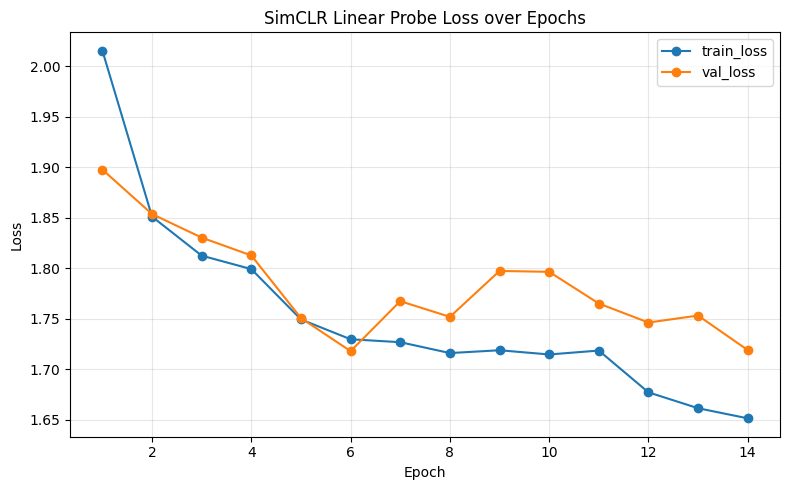

Saved loss curve to: /content/bostongene_project/image_classification_project/reports/figures/14_simclr_linear_probe_loss_curve.png


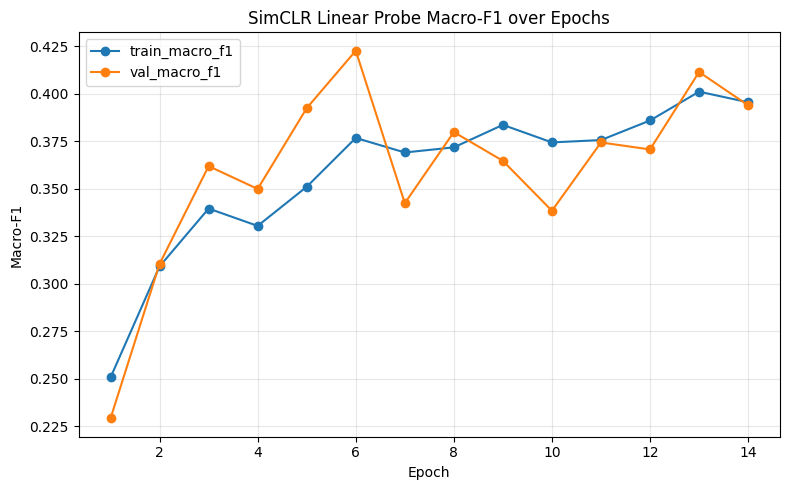

Saved macro-F1 curve to: /content/bostongene_project/image_classification_project/reports/figures/15_simclr_linear_probe_macro_f1_curve.png


In [ ]:
history_probe_df = pd.DataFrame(history_probe)

probe_history_path = OUTPUTS_DIR / "simclr_linear_probe_history.csv"
history_probe_df.to_csv(probe_history_path, index=False)

display(history_probe_df.head())
display(history_probe_df.tail())

print(f"Saved linear probe history to: {probe_history_path}")


fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(history_probe_df["epoch"], history_probe_df["train_loss"], marker="o", label="train_loss")
ax.plot(history_probe_df["epoch"], history_probe_df["val_loss"], marker="o", label="val_loss")

ax.set_title("SimCLR Linear Probe Loss over Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

probe_loss_fig_path = FIGURES_DIR / "14_simclr_linear_probe_loss_curve.png"
fig.savefig(probe_loss_fig_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved loss curve to: {probe_loss_fig_path}")


fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(history_probe_df["epoch"], history_probe_df["train_macro_f1"], marker="o", label="train_macro_f1")
ax.plot(history_probe_df["epoch"], history_probe_df["val_macro_f1"], marker="o", label="val_macro_f1")

ax.set_title("SimCLR Linear Probe Macro-F1 over Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Macro-F1")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

probe_f1_fig_path = FIGURES_DIR / "15_simclr_linear_probe_macro_f1_curve.png"
fig.savefig(probe_f1_fig_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved macro-F1 curve to: {probe_f1_fig_path}")

In [ ]:
checkpoint_probe = torch.load(best_probe_path, map_location=device)

# Recreate encoder
encoder_probe = resnet18(weights=None)
feature_dim = encoder_probe.fc.in_features
encoder_probe.fc = nn.Identity()
encoder_probe.load_state_dict(checkpoint_probe["encoder_state_dict"])
encoder_probe = encoder_probe.to(device)

# Recreate linear probe model
linear_probe_model = SSLLinearProbe(
    encoder=encoder_probe,
    feature_dim=feature_dim,
    num_classes=NUM_CLASSES,
).to(device)

linear_probe_model.load_state_dict(checkpoint_probe["model_state_dict"])

test_metrics_probe, y_true_probe, y_pred_probe = evaluate_probe(
    model=linear_probe_model,
    loader=test_loader_probe,
    criterion=criterion_probe,
    device=device,
    return_predictions=True,
)

print("Best checkpoint epoch:", checkpoint_probe["epoch"])
print("Validation macro-F1 at checkpoint:", checkpoint_probe["val_macro_f1"])

print("\nSimCLR linear probe test metrics:")
for key, value in test_metrics_probe.items():
    print(f"{key}: {value:.4f}")

Best checkpoint epoch: 6
Validation macro-F1 at checkpoint: 0.42275255389508826

SimCLR linear probe test metrics:
accuracy: 0.3879
macro_f1: 0.3611
balanced_accuracy: 0.3805
loss: 1.7649


               precision    recall  f1-score   support

      ArtDeco       0.22      0.22      0.22         9
       Cubism       0.55      0.40      0.46        55
Impressionism       0.35      0.47      0.40        36
     Japonism       0.42      0.52      0.46        31
   Naturalism       0.27      0.18      0.22        33
       Rococo       0.36      0.28      0.31        18
      cartoon       0.32      0.55      0.40        11
        photo       0.39      0.43      0.41        21

     accuracy                           0.39       214
    macro avg       0.36      0.38      0.36       214
 weighted avg       0.40      0.39      0.38       214

Saved classification report to: /content/bostongene_project/image_classification_project/outputs/simclr_linear_probe_classification_report.txt


,ArtDeco,Cubism,Impressionism,Japonism,Naturalism,Rococo,cartoon,photo
ArtDeco,2,1,0,3,1,2,0,0
Cubism,2,22,12,7,8,2,0,2
Impressionism,0,5,17,3,3,3,2,3
Japonism,2,1,6,16,2,0,3,1
Naturalism,0,7,6,5,6,1,6,2
Rococo,3,0,4,1,0,5,0,5
cartoon,0,1,1,1,1,0,6,1
photo,0,3,3,2,1,1,2,9


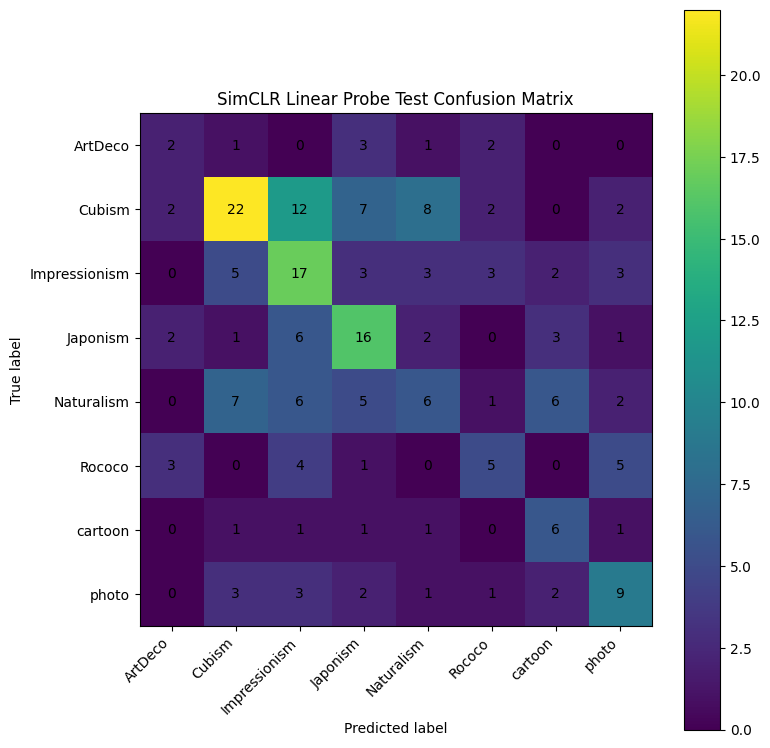

Saved confusion matrix CSV to: /content/bostongene_project/image_classification_project/outputs/simclr_linear_probe_confusion_matrix.csv
Saved confusion matrix figure to: /content/bostongene_project/image_classification_project/reports/figures/16_simclr_linear_probe_confusion_matrix.png


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

report_text_probe = classification_report(
    y_true_probe,
    y_pred_probe,
    target_names=class_names_probe,
    zero_division=0,
)

print(report_text_probe)

report_path_probe = OUTPUTS_DIR / "simclr_linear_probe_classification_report.txt"

with open(report_path_probe, "w", encoding="utf-8") as f:
    f.write(report_text_probe)

print(f"Saved classification report to: {report_path_probe}")


cm_probe = confusion_matrix(y_true_probe, y_pred_probe)

cm_probe_df = pd.DataFrame(
    cm_probe,
    index=class_names_probe,
    columns=class_names_probe,
)

cm_path_probe = OUTPUTS_DIR / "simclr_linear_probe_confusion_matrix.csv"
cm_probe_df.to_csv(cm_path_probe)

display(cm_probe_df)

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(cm_probe)

ax.set_title("SimCLR Linear Probe Test Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_xticks(np.arange(len(class_names_probe)))
ax.set_yticks(np.arange(len(class_names_probe)))

ax.set_xticklabels(class_names_probe, rotation=45, ha="right")
ax.set_yticklabels(class_names_probe)

for i in range(cm_probe.shape[0]):
    for j in range(cm_probe.shape[1]):
        ax.text(j, i, str(cm_probe[i, j]), ha="center", va="center")

fig.colorbar(im, ax=ax)
fig.tight_layout()

cm_fig_path_probe = FIGURES_DIR / "16_simclr_linear_probe_confusion_matrix.png"
fig.savefig(cm_fig_path_probe, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved confusion matrix CSV to: {cm_path_probe}")
print(f"Saved confusion matrix figure to: {cm_fig_path_probe}")

In [ ]:
comparison_ssl_df = pd.DataFrame([
    {
        "model": "SimpleCNN from scratch",
        "training_type": "Supervised from scratch",
        "input_size": 128,
        "test_accuracy": 0.5421,
        "test_macro_f1": 0.4947,
        "test_balanced_accuracy": 0.5174,
    },
    {
        "model": "ResNet18 transfer learning",
        "training_type": "Supervised ImageNet transfer",
        "input_size": 128,
        "test_accuracy": 0.7570,
        "test_macro_f1": 0.7324,
        "test_balanced_accuracy": 0.7629,
    },
    {
        "model": "SimCLR + linear probe",
        "training_type": "Self-supervised pretraining + frozen linear probe",
        "input_size": 128,
        "test_accuracy": test_metrics_probe["accuracy"],
        "test_macro_f1": test_metrics_probe["macro_f1"],
        "test_balanced_accuracy": test_metrics_probe["balanced_accuracy"],
    },
])

comparison_ssl_path = OUTPUTS_DIR / "simclr_classifier_comparison.csv"
comparison_ssl_df.to_csv(comparison_ssl_path, index=False)

display(comparison_ssl_df)

print(f"Saved SSL comparison table to: {comparison_ssl_path}")

,model,training_type,input_size,test_accuracy,test_macro_f1,test_balanced_accuracy
0,SimpleCNN from scratch,Supervised from scratch,128,0.54210,0.494700,0.517400
1,ResNet18 transfer learning,Supervised ImageNet transfer,128,0.75700,0.732400,0.762900
2,SimCLR + linear probe,Self-supervised pretraining + frozen linear probe,128,0.38785,0.361115,0.380524


Saved SSL comparison table to: /content/bostongene_project/image_classification_project/outputs/simclr_classifier_comparison.csv


In [ ]:
from pathlib import Path
import shutil
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    DRIVE_RESULTS_DIR = Path("/content/drive/MyDrive/bostongene_project/simclr_results")
    DRIVE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    for folder_name in ["models", "outputs", "reports"]:
        src = PROJECT_ROOT / folder_name
        dst = DRIVE_RESULTS_DIR / folder_name

        if src.exists():
            shutil.copytree(src, dst, dirs_exist_ok=True)
            print(f"Copied {src} -> {dst}")

    print("Saved updated SimCLR results to Google Drive:", DRIVE_RESULTS_DIR)
else:
    print("Not running in Colab, no Drive backup needed.")

Copied /content/bostongene_project/image_classification_project/models -> /content/drive/MyDrive/bostongene_project/simclr_results/models
Copied /content/bostongene_project/image_classification_project/outputs -> /content/drive/MyDrive/bostongene_project/simclr_results/outputs
Copied /content/bostongene_project/image_classification_project/reports -> /content/drive/MyDrive/bostongene_project/simclr_results/reports
Saved updated SimCLR results to Google Drive: /content/drive/MyDrive/bostongene_project/simclr_results


## Downstream Evaluation: SimCLR Fine-Tuning

The frozen linear probe evaluates the quality of the self-supervised representation without changing the encoder. However, this can underestimate performance because the encoder is not allowed to adapt to the painting-style classification task.

In this section, the SimCLR-pretrained encoder is fine-tuned end-to-end with a supervised classifier head. This keeps the self-supervised initialization but allows the full network to adapt to the 8 art-style labels.

In [ ]:
import time
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torchvision.models import resnet18
from sklearn.metrics import classification_report, confusion_matrix

from src.data import compute_class_weights
from src.metrics import compute_metrics
from src.config import MODELS_DIR, OUTPUTS_DIR, FIGURES_DIR, NUM_CLASSES


# ------------------------------------------------------------
# 1. Load best SimCLR linear-probe checkpoint
# ------------------------------------------------------------

best_probe_path = MODELS_DIR / "simclr_linear_probe.pt"

assert best_probe_path.exists(), f"Linear probe checkpoint not found: {best_probe_path}"

checkpoint_probe = torch.load(best_probe_path, map_location=device)

print("Loaded linear-probe checkpoint:")
print("Epoch:", checkpoint_probe["epoch"])
print("Validation macro-F1:", checkpoint_probe["val_macro_f1"])


# ------------------------------------------------------------
# 2. Recreate SimCLR encoder
# ------------------------------------------------------------

encoder_ft = resnet18(weights=None)
feature_dim = encoder_ft.fc.in_features
encoder_ft.fc = nn.Identity()

encoder_ft.load_state_dict(checkpoint_probe["encoder_state_dict"])


# ------------------------------------------------------------
# 3. Define fine-tuning model
# ------------------------------------------------------------

class SimCLRFineTuneClassifier(nn.Module):
    """
    SimCLR-pretrained ResNet18 encoder + classifier head.

    Unlike the linear probe, the encoder is unfrozen and fine-tuned.
    """

    def __init__(self, encoder, feature_dim: int, num_classes: int, dropout: float = 0.35):
        super().__init__()

        self.encoder = encoder

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(feature_dim, num_classes),
        )

    def forward(self, x):
        features = self.encoder(x)
        logits = self.classifier(features)
        return logits


finetune_model = SimCLRFineTuneClassifier(
    encoder=encoder_ft,
    feature_dim=feature_dim,
    num_classes=NUM_CLASSES,
    dropout=0.35,
).to(device)


# ------------------------------------------------------------
# 4. Initialize classifier head from linear probe if possible
# ------------------------------------------------------------

try:
    linear_probe_classifier_state = checkpoint_probe["classifier_state_dict"]

    # Our fine-tune classifier is Sequential(Dropout, Linear),
    # so the Linear layer is classifier[1].
    finetune_model.classifier[1].load_state_dict(linear_probe_classifier_state)

    print("Loaded classifier weights from linear probe.")
except Exception as e:
    print("Could not load linear-probe classifier head. Starting classifier head from scratch.")
    print("Reason:", repr(e))


# ------------------------------------------------------------
# 5. Unfreeze all encoder parameters
# ------------------------------------------------------------

for param in finetune_model.encoder.parameters():
    param.requires_grad = True

for param in finetune_model.classifier.parameters():
    param.requires_grad = True


print("Fine-tuning model is ready.")
print("Feature dimension:", feature_dim)

Loaded linear-probe checkpoint:
Epoch: 6
Validation macro-F1: 0.42275255389508826
Loaded classifier weights from linear probe.
Fine-tuning model is ready.
Feature dimension: 512


In [ ]:
# ------------------------------------------------------------
# Loss: weighted CE + label smoothing
# ------------------------------------------------------------

class_weights_ft = compute_class_weights(train_dataset_probe).to(device)

criterion_ft = nn.CrossEntropyLoss(
    weight=class_weights_ft,
    label_smoothing=0.05,
)


# ------------------------------------------------------------
# Optimizer with different learning rates
# ------------------------------------------------------------
# Encoder gets a small LR because it already has SSL-pretrained features.
# Classifier head gets a larger LR because it must adapt to labels.

encoder_params = list(finetune_model.encoder.parameters())
classifier_params = list(finetune_model.classifier.parameters())

optimizer_ft = torch.optim.AdamW(
    [
        {"params": encoder_params, "lr": 3e-5},
        {"params": classifier_params, "lr": 5e-4},
    ],
    weight_decay=1e-4,
)

scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft,
    mode="max",
    factor=0.5,
    patience=4,
)


print("Class weights:")
for class_name, weight in zip(class_names_probe, class_weights_ft.detach().cpu().numpy()):
    print(f"{class_name}: {weight:.3f}")

print("\nOptimizer:")
print(optimizer_ft)

Class weights:
ArtDeco: 2.704
Cubism: 0.488
Impressionism: 0.740
Japonism: 0.876
Naturalism: 0.813
Rococo: 1.517
cartoon: 2.392
photo: 1.282

Optimizer:
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 3e-05
    maximize: False
    weight_decay: 0.0001

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0005
    maximize: False
    weight_decay: 0.0001
)


In [ ]:
def train_finetune_one_epoch(model, loader, criterion, optimizer, device):
    """
    Fine-tune encoder + classifier for one epoch.
    """
    model.train()

    running_loss = 0.0
    all_labels = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)

        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)

    metrics = compute_metrics(all_labels, all_preds)
    metrics["loss"] = epoch_loss

    return metrics


@torch.no_grad()
def evaluate_finetune(model, loader, criterion, device, return_predictions=False):
    """
    Evaluate fine-tuned model.
    """
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)

        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)

    metrics = compute_metrics(all_labels, all_preds)
    metrics["loss"] = epoch_loss

    if return_predictions:
        return metrics, all_labels, all_preds

    return metrics


print("Fine-tuning functions are ready.")

Fine-tuning functions are ready.


In [ ]:
EPOCHS_FT = 30
PATIENCE_FT = 8

best_val_macro_f1_ft = -1.0
epochs_without_improvement_ft = 0

history_ft = []

best_ft_path = MODELS_DIR / "simclr_finetuned_classifier.pt"

print(f"Fine-tuning SimCLR encoder for {EPOCHS_FT} epochs")
print(f"Best model will be saved to: {best_ft_path}")

start_time = time.time()

for epoch in range(1, EPOCHS_FT + 1):
    epoch_start = time.time()

    train_metrics = train_finetune_one_epoch(
        model=finetune_model,
        loader=train_loader_probe,
        criterion=criterion_ft,
        optimizer=optimizer_ft,
        device=device,
    )

    val_metrics = evaluate_finetune(
        model=finetune_model,
        loader=val_loader_probe,
        criterion=criterion_ft,
        device=device,
    )

    scheduler_ft.step(val_metrics["macro_f1"])

    current_lr_encoder = optimizer_ft.param_groups[0]["lr"]
    current_lr_classifier = optimizer_ft.param_groups[1]["lr"]

    row = {
        "epoch": epoch,
        "lr_encoder": current_lr_encoder,
        "lr_classifier": current_lr_classifier,

        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "train_balanced_accuracy": train_metrics["balanced_accuracy"],

        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
    }

    history_ft.append(row)

    improved = val_metrics["macro_f1"] > best_val_macro_f1_ft

    if improved:
        best_val_macro_f1_ft = val_metrics["macro_f1"]
        epochs_without_improvement_ft = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": finetune_model.state_dict(),
                "encoder_state_dict": finetune_model.encoder.state_dict(),
                "classifier_state_dict": finetune_model.classifier.state_dict(),
                "class_names": class_names_probe,
                "val_macro_f1": best_val_macro_f1_ft,
                "config": {
                    "method": "SimCLR fine-tuning",
                    "img_size": IMG_SIZE_PROBE,
                    "batch_size": BATCH_SIZE_PROBE,
                    "encoder": "ResNet18 pretrained with SimCLR on train split only",
                    "encoder_frozen": False,
                    "loss": "Weighted CrossEntropyLoss with label_smoothing=0.05",
                    "lr_encoder": 3e-5,
                    "lr_classifier": 5e-4,
                },
            },
            best_ft_path,
        )
    else:
        epochs_without_improvement_ft += 1

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch {epoch:02d}/{EPOCHS_FT} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"train_macro_f1={train_metrics['macro_f1']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_macro_f1={val_metrics['macro_f1']:.4f} | "
        f"val_bal_acc={val_metrics['balanced_accuracy']:.4f} | "
        f"lr_encoder={current_lr_encoder:.6f} | "
        f"lr_classifier={current_lr_classifier:.6f} | "
        f"time={epoch_time:.1f}s"
    )

    if epochs_without_improvement_ft >= PATIENCE_FT:
        print(f"Early stopping after {epoch} epochs.")
        break

total_time = time.time() - start_time

print(f"SimCLR fine-tuning finished in {total_time / 60:.2f} minutes.")
print(f"Best validation macro-F1: {best_val_macro_f1_ft:.4f}")

Fine-tuning SimCLR encoder for 30 epochs
Best model will be saved to: /content/bostongene_project/image_classification_project/models/simclr_finetuned_classifier.pt
Epoch 01/30 | train_loss=1.1645 | train_macro_f1=0.6068 | val_loss=1.5983 | val_macro_f1=0.4203 | val_bal_acc=0.4586 | lr_encoder=0.000004 | lr_classifier=0.000063 | time=9.1s
Epoch 02/30 | train_loss=1.1880 | train_macro_f1=0.6090 | val_loss=1.5897 | val_macro_f1=0.4404 | val_bal_acc=0.4639 | lr_encoder=0.000004 | lr_classifier=0.000063 | time=5.9s
Epoch 03/30 | train_loss=1.1630 | train_macro_f1=0.6220 | val_loss=1.5953 | val_macro_f1=0.4243 | val_bal_acc=0.4581 | lr_encoder=0.000004 | lr_classifier=0.000063 | time=7.6s
Epoch 04/30 | train_loss=1.1636 | train_macro_f1=0.6136 | val_loss=1.6231 | val_macro_f1=0.4333 | val_bal_acc=0.4550 | lr_encoder=0.000004 | lr_classifier=0.000063 | time=5.7s
Epoch 05/30 | train_loss=1.1419 | train_macro_f1=0.6150 | val_loss=1.6293 | val_macro_f1=0.4367 | val_bal_acc=0.4627 | lr_encoder=0

,epoch,lr_encoder,lr_classifier,train_loss,train_accuracy,train_macro_f1,train_balanced_accuracy,val_loss,val_accuracy,val_macro_f1,val_balanced_accuracy
0,1,0.000004,0.000063,1.164481,0.602010,0.606752,0.662602,1.598277,0.422535,0.420303,0.458612
1,2,0.000004,0.000063,1.187974,0.603015,0.608956,0.660167,1.589677,0.446009,0.440412,0.463924
2,3,0.000004,0.000063,1.162988,0.624121,0.621954,0.678333,1.595338,0.422535,0.424266,0.458132
3,4,0.000004,0.000063,1.163563,0.612060,0.613647,0.664406,1.623084,0.427230,0.433300,0.455007
4,5,0.000002,0.000031,1.141879,0.611055,0.615009,0.674899,1.629287,0.431925,0.436725,0.462701


,epoch,lr_encoder,lr_classifier,train_loss,train_accuracy,train_macro_f1,train_balanced_accuracy,val_loss,val_accuracy,val_macro_f1,val_balanced_accuracy
15,16,1.875000e-06,0.000031,1.084553,0.629146,0.634280,0.686383,1.605691,0.431925,0.430649,0.454094
16,17,9.375000e-07,0.000016,1.091118,0.638191,0.645002,0.702714,1.632748,0.431925,0.427843,0.462962
17,18,9.375000e-07,0.000016,1.106035,0.642211,0.642403,0.695773,1.623496,0.431925,0.428249,0.460807
18,19,9.375000e-07,0.000016,1.108355,0.642211,0.648242,0.702639,1.630286,0.422535,0.421748,0.461502
19,20,9.375000e-07,0.000016,1.098614,0.642211,0.645235,0.696238,1.618041,0.446009,0.444322,0.466860


Saved fine-tuning history to: /content/bostongene_project/image_classification_project/outputs/simclr_finetune_history.csv


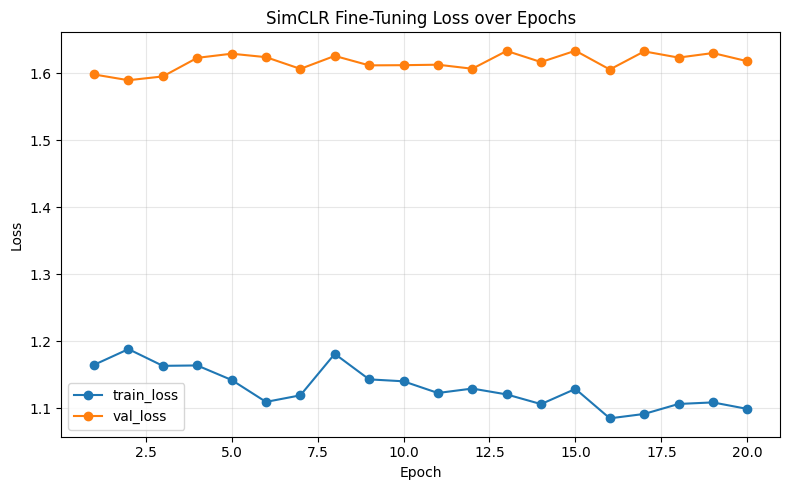

Saved fine-tuning loss curve to: /content/bostongene_project/image_classification_project/reports/figures/17_simclr_finetune_loss_curve.png


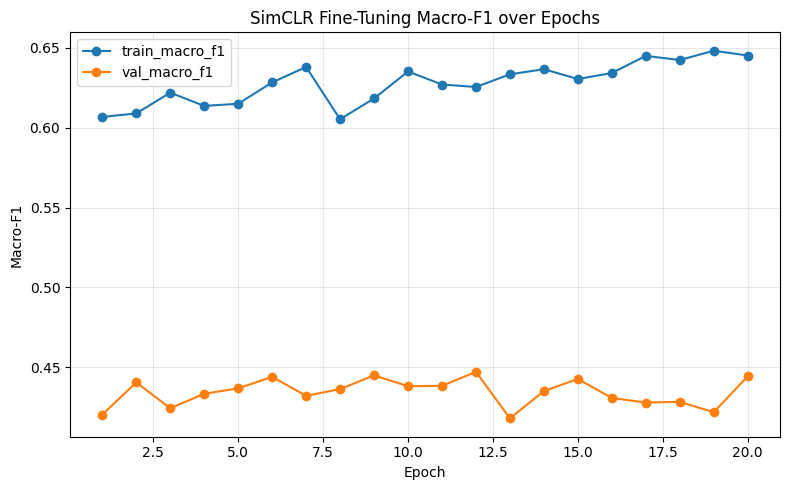

Saved fine-tuning macro-F1 curve to: /content/bostongene_project/image_classification_project/reports/figures/18_simclr_finetune_macro_f1_curve.png


In [ ]:
history_ft_df = pd.DataFrame(history_ft)

ft_history_path = OUTPUTS_DIR / "simclr_finetune_history.csv"
history_ft_df.to_csv(ft_history_path, index=False)

display(history_ft_df.head())
display(history_ft_df.tail())

print(f"Saved fine-tuning history to: {ft_history_path}")


# ------------------------------------------------------------
# Loss curve
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(history_ft_df["epoch"], history_ft_df["train_loss"], marker="o", label="train_loss")
ax.plot(history_ft_df["epoch"], history_ft_df["val_loss"], marker="o", label="val_loss")

ax.set_title("SimCLR Fine-Tuning Loss over Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

ft_loss_fig_path = FIGURES_DIR / "17_simclr_finetune_loss_curve.png"
fig.savefig(ft_loss_fig_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved fine-tuning loss curve to: {ft_loss_fig_path}")


# ------------------------------------------------------------
# Macro-F1 curve
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(history_ft_df["epoch"], history_ft_df["train_macro_f1"], marker="o", label="train_macro_f1")
ax.plot(history_ft_df["epoch"], history_ft_df["val_macro_f1"], marker="o", label="val_macro_f1")

ax.set_title("SimCLR Fine-Tuning Macro-F1 over Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Macro-F1")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

ft_f1_fig_path = FIGURES_DIR / "18_simclr_finetune_macro_f1_curve.png"
fig.savefig(ft_f1_fig_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved fine-tuning macro-F1 curve to: {ft_f1_fig_path}")

In [ ]:
checkpoint_ft = torch.load(best_ft_path, map_location=device)

# Recreate encoder
encoder_ft_eval = resnet18(weights=None)
feature_dim = encoder_ft_eval.fc.in_features
encoder_ft_eval.fc = nn.Identity()
encoder_ft_eval.load_state_dict(checkpoint_ft["encoder_state_dict"])

# Recreate model
finetune_model_eval = SimCLRFineTuneClassifier(
    encoder=encoder_ft_eval,
    feature_dim=feature_dim,
    num_classes=NUM_CLASSES,
    dropout=0.35,
).to(device)

finetune_model_eval.load_state_dict(checkpoint_ft["model_state_dict"])

test_metrics_ft, y_true_ft, y_pred_ft = evaluate_finetune(
    model=finetune_model_eval,
    loader=test_loader_probe,
    criterion=criterion_ft,
    device=device,
    return_predictions=True,
)

print("Best checkpoint epoch:", checkpoint_ft["epoch"])
print("Validation macro-F1 at checkpoint:", checkpoint_ft["val_macro_f1"])

print("\nSimCLR fine-tuned test metrics:")
for key, value in test_metrics_ft.items():
    print(f"{key}: {value:.4f}")

Best checkpoint epoch: 12
Validation macro-F1 at checkpoint: 0.44704275998774246

SimCLR fine-tuned test metrics:
accuracy: 0.4813
macro_f1: 0.4684
balanced_accuracy: 0.4892
loss: 1.5961


               precision    recall  f1-score   support

      ArtDeco       0.30      0.33      0.32         9
       Cubism       0.62      0.42      0.50        55
Impressionism       0.52      0.44      0.48        36
     Japonism       0.46      0.74      0.57        31
   Naturalism       0.32      0.30      0.31        33
       Rococo       0.62      0.56      0.59        18
      cartoon       0.33      0.55      0.41        11
        photo       0.57      0.57      0.57        21

     accuracy                           0.48       214
    macro avg       0.47      0.49      0.47       214
 weighted avg       0.50      0.48      0.48       214

Saved classification report to: /content/bostongene_project/image_classification_project/outputs/simclr_finetune_classification_report.txt


,ArtDeco,Cubism,Impressionism,Japonism,Naturalism,Rococo,cartoon,photo
ArtDeco,3,1,0,3,0,1,0,1
Cubism,6,23,4,11,7,0,3,1
Impressionism,0,4,16,3,8,2,1,2
Japonism,0,2,3,23,2,0,1,0
Naturalism,0,5,3,7,10,2,5,1
Rococo,1,0,2,0,2,10,0,3
cartoon,0,1,1,1,1,0,6,1
photo,0,1,2,2,1,1,2,12


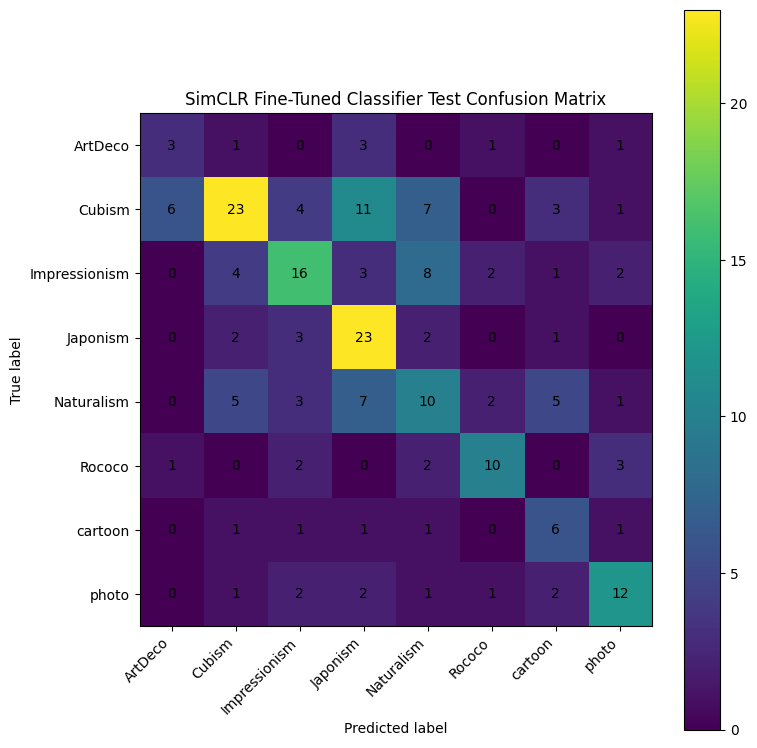

Saved confusion matrix CSV to: /content/bostongene_project/image_classification_project/outputs/simclr_finetune_confusion_matrix.csv
Saved confusion matrix figure to: /content/bostongene_project/image_classification_project/reports/figures/19_simclr_finetune_confusion_matrix.png


In [ ]:
report_text_ft = classification_report(
    y_true_ft,
    y_pred_ft,
    target_names=class_names_probe,
    zero_division=0,
)

print(report_text_ft)

report_path_ft = OUTPUTS_DIR / "simclr_finetune_classification_report.txt"

with open(report_path_ft, "w", encoding="utf-8") as f:
    f.write(report_text_ft)

print(f"Saved classification report to: {report_path_ft}")


cm_ft = confusion_matrix(y_true_ft, y_pred_ft)

cm_ft_df = pd.DataFrame(
    cm_ft,
    index=class_names_probe,
    columns=class_names_probe,
)

cm_path_ft = OUTPUTS_DIR / "simclr_finetune_confusion_matrix.csv"
cm_ft_df.to_csv(cm_path_ft)

display(cm_ft_df)

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(cm_ft)

ax.set_title("SimCLR Fine-Tuned Classifier Test Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_xticks(np.arange(len(class_names_probe)))
ax.set_yticks(np.arange(len(class_names_probe)))

ax.set_xticklabels(class_names_probe, rotation=45, ha="right")
ax.set_yticklabels(class_names_probe)

for i in range(cm_ft.shape[0]):
    for j in range(cm_ft.shape[1]):
        ax.text(j, i, str(cm_ft[i, j]), ha="center", va="center")

fig.colorbar(im, ax=ax)
fig.tight_layout()

cm_fig_path_ft = FIGURES_DIR / "19_simclr_finetune_confusion_matrix.png"
fig.savefig(cm_fig_path_ft, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved confusion matrix CSV to: {cm_path_ft}")
print(f"Saved confusion matrix figure to: {cm_fig_path_ft}")

In [ ]:
comparison_ssl_full_df = pd.DataFrame([
    {
        "model": "SimpleCNN from scratch",
        "training_type": "Supervised from scratch",
        "input_size": 128,
        "test_accuracy": 0.5421,
        "test_macro_f1": 0.4947,
        "test_balanced_accuracy": 0.5174,
    },
    {
        "model": "ResNet18 transfer learning",
        "training_type": "Supervised ImageNet transfer",
        "input_size": 128,
        "test_accuracy": 0.7570,
        "test_macro_f1": 0.7324,
        "test_balanced_accuracy": 0.7629,
    },
    {
        "model": "SimCLR + frozen linear probe",
        "training_type": "Self-supervised pretraining + frozen linear probe",
        "input_size": 128,
        "test_accuracy": 0.3879,
        "test_macro_f1": 0.3611,
        "test_balanced_accuracy": 0.3805,
    },
    {
        "model": "SimCLR + fine-tuning",
        "training_type": "Self-supervised pretraining + supervised fine-tuning",
        "input_size": 128,
        "test_accuracy": test_metrics_ft["accuracy"],
        "test_macro_f1": test_metrics_ft["macro_f1"],
        "test_balanced_accuracy": test_metrics_ft["balanced_accuracy"],
    },
])

comparison_ssl_full_path = OUTPUTS_DIR / "simclr_full_comparison.csv"
comparison_ssl_full_df.to_csv(comparison_ssl_full_path, index=False)

display(comparison_ssl_full_df)

print(f"Saved full SSL comparison table to: {comparison_ssl_full_path}")

,model,training_type,input_size,test_accuracy,test_macro_f1,test_balanced_accuracy
0,SimpleCNN from scratch,Supervised from scratch,128,0.542100,0.494700,0.517400
1,ResNet18 transfer learning,Supervised ImageNet transfer,128,0.757000,0.732400,0.762900
2,SimCLR + frozen linear probe,Self-supervised pretraining + frozen linear probe,128,0.387900,0.361100,0.380500
3,SimCLR + fine-tuning,Self-supervised pretraining + supervised fine-...,128,0.481308,0.468407,0.489171


Saved full SSL comparison table to: /content/bostongene_project/image_classification_project/outputs/simclr_full_comparison.csv


In [ ]:
from pathlib import Path
import shutil
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    DRIVE_RESULTS_DIR = Path("/content/drive/MyDrive/bostongene_project/simclr_results")
    DRIVE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    for folder_name in ["models", "outputs", "reports"]:
        src = PROJECT_ROOT / folder_name
        dst = DRIVE_RESULTS_DIR / folder_name

        if src.exists():
            shutil.copytree(src, dst, dirs_exist_ok=True)
            print(f"Copied {src} -> {dst}")

    print("Saved updated SimCLR fine-tuning results to Google Drive:", DRIVE_RESULTS_DIR)
else:
    print("Not running in Colab, no Drive backup needed.")

Copied /content/bostongene_project/image_classification_project/models -> /content/drive/MyDrive/bostongene_project/simclr_results/models
Copied /content/bostongene_project/image_classification_project/outputs -> /content/drive/MyDrive/bostongene_project/simclr_results/outputs
Copied /content/bostongene_project/image_classification_project/reports -> /content/drive/MyDrive/bostongene_project/simclr_results/reports
Saved updated SimCLR fine-tuning results to Google Drive: /content/drive/MyDrive/bostongene_project/simclr_results
